In [316]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tools.tools import *
from tools.bag_to_df import bag_topic_to_dataframe
import pandas as pd
from scipy.spatial.transform import Rotation as R
from tools.signal_properties import compare_signals


%load_ext autoreload
%autoreload 2

REAL_BAG_PATH = "/root/stonefish_ros2_ws/sintef_dataset/2024-08-22_14-29-05_data.bag"
SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_11_14-13_14_57"



# Test:
# SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_11_14-13_53_59" # I (0.0 0.0 0.0)
# SIM_BAG_PATH = "/root/stonefish_ros2_ws/recorded_data/simulation/rosbag2_2025_11_14-14_47_21" # I (1.0 1.0 1.0)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [317]:
print_bag_topics(REAL_BAG_PATH)

Topics and message types:
/bluerov2/alive                                std_msgs/msg/Float32
/bluerov2/armed                                std_msgs/msg/Float32
/bluerov2/battery                              messages/msg/BatteryStatus
/bluerov2/modes                                joystick/msg/ModeManager2
/commanded_thrust                              rospy_tutorials/msg/Floats
/controller/x                                  messages/msg/MRACOupdate
/controller/y                                  messages/msg/MRACOupdate
/controller/yaw                                messages/msg/PIDState
/controller/z                                  messages/msg/PIDState
/gui/netFollowing_manager                      messages/msg/NetFollowingManager
/guidance                                      messages/msg/GuidanceManager
/joystick                                      joystick/msg/Joystick
/joystick/dvl_reset_position                   messages/msg/BoolStamped
/joystick/init                        

# Read data

In [318]:
from tools.data import Nucleus

xyz_post = np.array([23.5, 4.5, 0])
rpy_post = np.array([0, 0, -2.1])
ins_data = Nucleus(REAL_BAG_PATH, xyz_post, rpy_post)

nucleus_alitmeter = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/altimeter")
nucleus_bottomtrack = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/bottomtrack")
nucleus_magnetometer = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/magnetometer")
nucleus_watertrack = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/watertrack")


imu_sensor = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/imu")
nucleus_imu = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/nucleus1000dvl/imu")

# A50
dvl_a50_position = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/dvl_position")
dvl_a50_velocity = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/dvl_velocity")

# SIM
sim_dvl = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/dvl")
sim_a50 = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/dvl_a50")
sim_gt = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth")
sim_gt_dvl = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth_dvl")
sim_ins = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ins")
sim_imu = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/imu")
print("")

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')
/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


# Normalize time

Use the first element of ground truth running at 100 Hz as the starting point of time. Topics spawn after some time

In [319]:
imu = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/imu")
t0_real = imu["t"][0]

# Get t0 of simulation
t0_sim = sim_gt["t"].iloc[0] - 0.4


def set_t0(df: pd.DataFrame, t_0):
    df["t"] -= t_0

# Subtract t0
set_t0(sim_gt, t0_sim)
set_t0(sim_gt_dvl, t0_sim)
set_t0(sim_a50, t0_sim)
set_t0(sim_dvl, t0_sim)
set_t0(sim_ins, t0_sim)
set_t0(sim_imu, t0_sim)

ins_data.set_t0(t0_real)
set_t0(nucleus_alitmeter, t0_real)
set_t0(nucleus_bottomtrack, t0_real)
set_t0(nucleus_magnetometer, t0_real)
set_t0(nucleus_watertrack, t0_real)
set_t0(dvl_a50_position, t0_real)
set_t0(dvl_a50_velocity, t0_real)
set_t0(imu_sensor, t0_real)
set_t0(nucleus_imu, t0_real)


# Sway Velocity

Ground truth - simulated dvl:
{'rmse': 0.012483952661191934, 'corr': 0.9285207579359002, 'mean_error': 1.3988095878557288e-05, 'var_signal1': 0.0011220061248843037, 'var_signal2': 0.0010406078477693888, 'var_difference': 8.139827711491489e-05, 'var_ratio_s1_over_s2': 1.0782218558983554, 'cv_signal1': 0.35020662680159986, 'cv_signal2': 0.3372149225801888, 'kurtosis_signal1': 1.6209304909585285, 'kurtosis_signal2': 0.7474840220587695, 'kurtosis_difference': 0.873446468899759}

Ground truth - Real:
{'rmse': 0.029804036420508048, 'corr': 0.4420062240222768, 'mean_error': 0.002435064405037486, 'var_signal1': 0.0010567136817310981, 'var_signal2': 0.0004044251974366435, 'var_difference': 0.0006522884842944546, 'var_ratio_s1_over_s2': 2.61287795228595, 'cv_signal1': 0.3354824227282427, 'cv_signal2': 0.2024561822639328, 'kurtosis_signal1': 1.6066648488483146, 'kurtosis_signal2': 0.9658700025634435, 'kurtosis_difference': 0.6407948462848712}

Simulated - Real:
{'rmse': 0.028576602109059754, 'cor

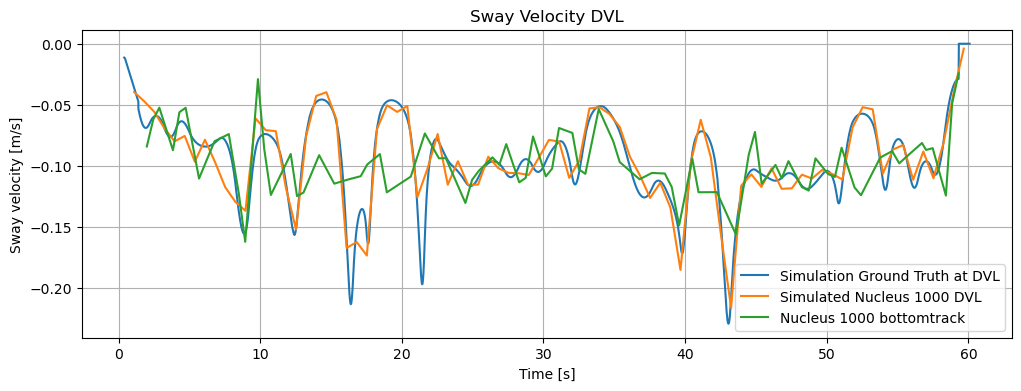

In [320]:
# Remove outlier value of dvl bottomtrack
nucleus_bottomtrack = nucleus_bottomtrack[nucleus_bottomtrack["dvl_velocity_xyz.x"] > 0]
nucleus_vel_xyz = np.array([nucleus_bottomtrack])

t_gt, data_gt = sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.y"].values
t_sim_dvl, data_sim_dvl = sim_dvl["t"].values, sim_dvl["velocity.y"].values
t_bt, data_bt = nucleus_bottomtrack["t"].values, -nucleus_bottomtrack["dvl_velocity_xyz.x"].values

# Remove lag from nucleus bottomtrack
lag_sec = get_signal_lag(t_bt, data_bt, t_gt, data_gt)
t_bt += lag_sec

plt.figure(figsize=(12, 4))

# --- GROUND THRUTH ---
plt.plot(t_gt, data_gt, label="Simulation Ground Truth at DVL")

# --- SIMULATED NUCLEUS ---
plt.plot(t_sim_dvl, data_sim_dvl, label="Simulated Nucleus 1000 DVL")

# --- NUCLEUS BOTTOMTRACK ---
plt.plot(t_bt, data_bt, label="Nucleus 1000 bottomtrack")

plt.title("Sway Velocity DVL")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

plt.legend()
plt.grid()

comp_simulated = compare_signals(t_gt, data_gt,
                        t_sim_dvl, data_sim_dvl)

comp_real      = compare_signals(t_gt, data_gt ,
                        t_bt, data_bt)

comp_real_vs_sim = compare_signals(t_sim_dvl, data_sim_dvl,
                        t_bt, data_bt)
print("Ground truth - simulated dvl:")
print(comp_simulated)
print("\nGround truth - Real:")
print(comp_real)
print("\nSimulated - Real:")
print(comp_real_vs_sim)

# DVL A50 velovity comparison

Simulated - Real:
{'rmse': 0.032902655085479474, 'corr': 0.511824758782203, 'mean_error': -0.0005332661697131693, 'var_signal1': 0.0013837751763395433, 'var_signal2': 0.000724704609501598, 'var_difference': 0.0006590705668379453, 'var_ratio_s1_over_s2': 1.909433385957361, 'cv_signal1': 0.39448447129317743, 'cv_signal2': 0.2871049039644968, 'kurtosis_signal1': 1.0024292430516528, 'kurtosis_signal2': 1.550336957556711, 'kurtosis_difference': -0.5479077145050582}


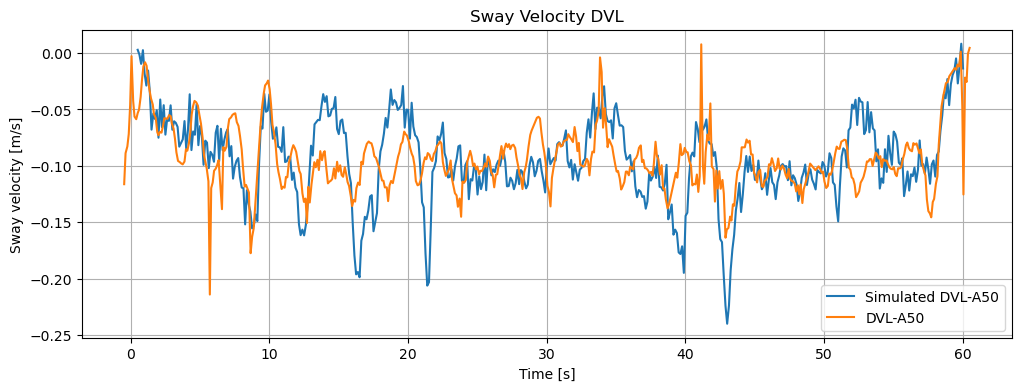

In [321]:
# Remove outlier value of dvl bottomtrack

t1, data1 = sim_a50["t"].values, sim_a50["velocity.y"].values
t2, data2 = dvl_a50_velocity["t"].values, -dvl_a50_velocity["velocity.x"].values

lag_sec = get_signal_lag(t1, data1, t2, data2)
t2 -= lag_sec

plt.figure(figsize=(12, 4))

# --- SIMULATED A50 ---
plt.plot(t1, data1, label="Simulated DVL-A50")

# --- REAL A50 ---
plt.plot(t2, data2, label="DVL-A50")


plt.title("Sway Velocity DVL")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

plt.legend()
plt.grid()

comp_real_vs_sim = compare_signals(t1, data1,
                        t2, data2)
print("Simulated - Real:")
print(comp_real_vs_sim)

Diskusjon: Erroren vil forplante seg gjennom rekonstrueringen av signalet

# Position comparison

{'rmse': 0.0060662798228280496, 'corr': 0.997448853403387, 'mean_error': -0.00013515419568970445, 'var_signal1': 0.006956314672209228, 'var_signal2': 0.007117013921000629, 'var_difference': -0.00016069924879140093, 'var_ratio_s1_over_s2': 0.9774204110635198, 'cv_signal1': 0.003437075292860755, 'cv_signal2': 0.0034765295491899096, 'kurtosis_signal1': -0.8720044748093803, 'kurtosis_signal2': -0.8957697905836488, 'kurtosis_difference': 0.023765315774268547}
{'rmse': 0.013145463870343009, 'corr': 0.9999732469723062, 'mean_error': 0.0043404060143432555, 'var_signal1': 2.8735839691529357, 'var_signal2': 2.8754819660719653, 'var_difference': -0.0018979969190295876, 'var_ratio_s1_over_s2': 0.9993399378116697, 'cv_signal1': 146.58489770434207, 'cv_signal2': 234.73538841417442, 'kurtosis_signal1': -1.2192682657071985, 'kurtosis_signal2': -1.2175859500973525, 'kurtosis_difference': -0.0016823156098459968}
{'rmse': 0.009653911581741111, 'corr': 0.9829201779451749, 'mean_error': 0.00039530553733490

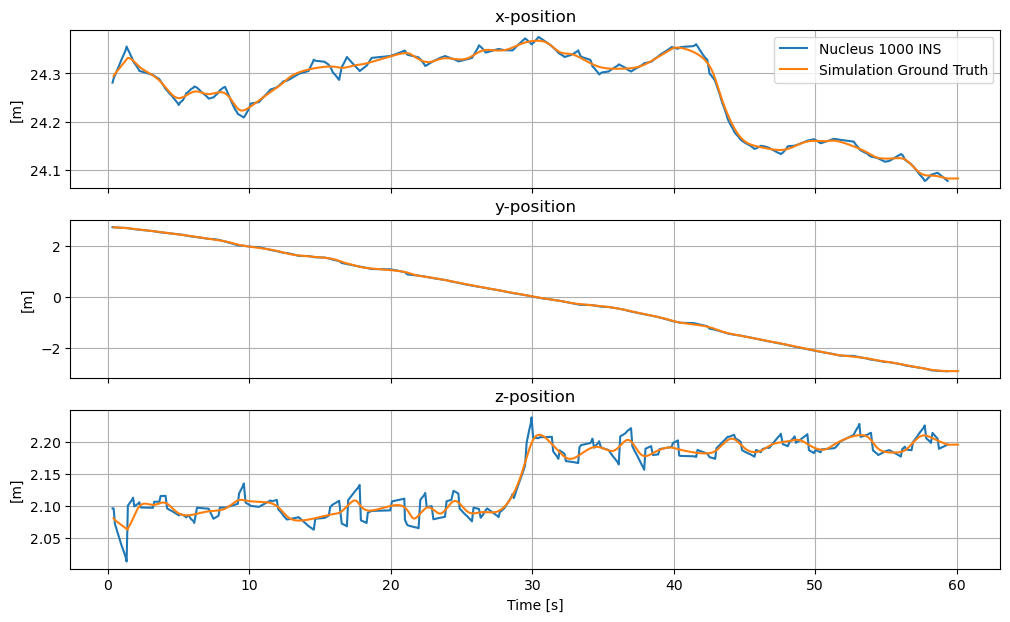

In [322]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(ins_data.t, ins_data.x, label="Nucleus 1000 INS")
axes[0].plot(sim_gt["t"].values, sim_gt["pose.pose.position.x"].values, label="Simulation Ground Truth")
axes[0].set_title("x-position")
axes[0].set_ylabel("[m]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ins_data.t, ins_data.y, label="Nucleus 1000 INS")
axes[1].plot(sim_gt["t"].values, sim_gt["pose.pose.position.y"].values, label="Simulation Ground Truth")
axes[1].set_title("y-position")
axes[1].set_ylabel("[m]")
# axes[1].legend()
axes[1].grid(True)

axes[2].plot(ins_data.t, ins_data.z, label="Nucleus 1000 INS")
axes[2].plot(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values, label="Simulation Ground Truth")
axes[2].set_title("z-position")
axes[2].set_ylabel("[m]")
axes[2].set_xlabel("Time [s]")
# axes[2].legend()
axes[2].grid(True)

comp_x = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.x"].values,
                        ins_data.t, ins_data.x)

comp_y = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.y"].values,
                        ins_data.t, ins_data.y)

comp_z = compare_signals(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values,
                        ins_data.t, ins_data.z)

print(comp_x)
print(comp_y)
print(comp_z)

# Velocity comparison
Diskuter hvor god banen som simuleres er i forhold til ground trurth

# Velocity comparison using Nucleus frame directly

{'rmse': 0.019634386126731577, 'corr': 0.7215918902234534, 'mean_error': -0.0017013622425956169, 'var_signal1': 0.0003102082340760863, 'var_signal2': 0.0007849237741645638, 'var_difference': -0.00047471554008847753, 'var_ratio_s1_over_s2': 0.3952081008200541, 'cv_signal1': 93.18733376132315, 'cv_signal2': 18.52502963869865, 'kurtosis_signal1': 4.324718352568874, 'kurtosis_signal2': -0.1326013992842534, 'kurtosis_difference': 4.457319751853127}
{'rmse': 0.03320627740044203, 'corr': 0.41237367577822964, 'mean_error': 0.0017103053283499588, 'var_signal1': 0.0011274021775959466, 'var_signal2': 0.0007127384690071104, 'var_difference': 0.00041466370858883627, 'var_ratio_s1_over_s2': 1.5817894313554999, 'cv_signal1': 0.35227835200356, 'cv_signal2': 0.2751615317195554, 'kurtosis_signal1': 1.4828805813106225, 'kurtosis_signal2': 0.840698418524874, 'kurtosis_difference': 0.6421821627857485}
{'rmse': 0.017833241638228338, 'corr': 0.6121617334514691, 'mean_error': -0.002192582941740248, 'var_signa

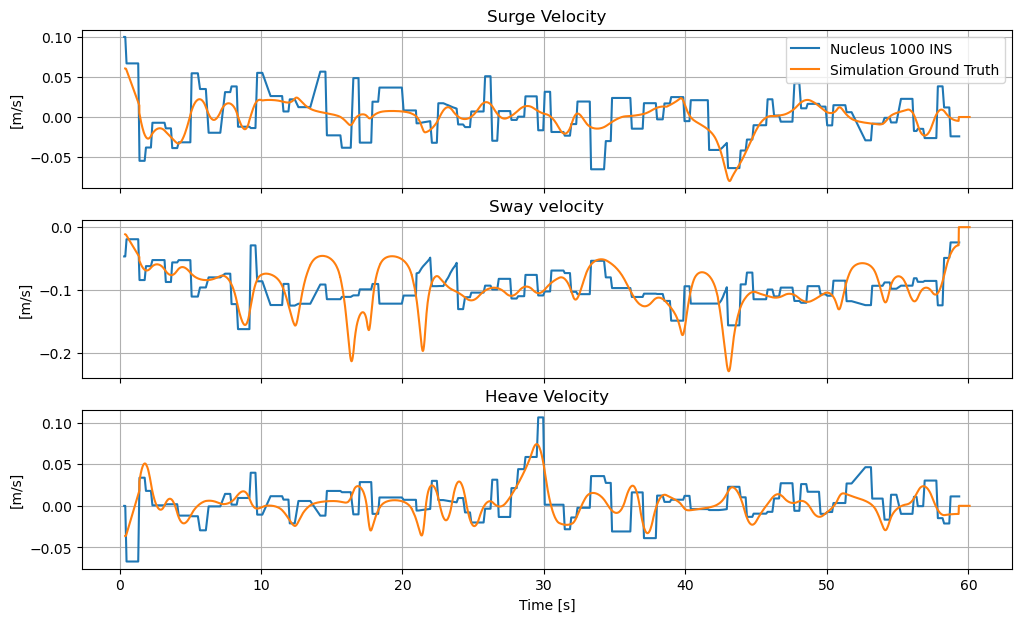

In [323]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

nucleus_ins = ins_data.df_ins

axes[0].plot(nucleus_ins["t"].values, nucleus_ins["velocityNucleus.z"].values, label="Nucleus 1000 INS")
axes[0].plot(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.x"].values, label="Simulation Ground Truth")
axes[0].set_title("Surge Velocity")
axes[0].set_ylabel("[m/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.x"].values)
axes[1].plot(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.y"].values)
axes[1].set_title("Sway velocity")
axes[1].set_ylabel("[m/s]")
axes[1].grid(True)


axes[2].plot(nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.y"].values)
axes[2].plot(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.z"].values)
axes[2].set_title("Heave Velocity")
axes[2].set_ylabel("[m/s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

comp_surge = compare_signals(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.x"].values,
                        nucleus_ins["t"].values, nucleus_ins["velocityNucleus.z"].values)

comp_sway = compare_signals(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.y"].values,
                        nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.x"].values)

comp_heave = compare_signals(sim_gt_dvl["t"].values, sim_gt_dvl["twist.twist.linear.z"].values,
                        nucleus_ins["t"].values, -nucleus_ins["velocityNucleus.y"].values)

print(comp_surge)
print(comp_sway)
print(comp_heave)

# Angular velocity comparison

{'rmse': 0.02912433493335051, 'corr': 0.16033942275394697, 'mean_error': -0.0010482809095428835, 'var_signal1': 0.00031020869800279854, 'var_signal2': 0.0006856618625009084, 'var_difference': -0.0003754531644981099, 'var_ratio_s1_over_s2': 0.4524222725051848, 'cv_signal1': 93.19257957340962, 'cv_signal2': 30.473075045821115, 'kurtosis_signal1': 4.324734959050714, 'kurtosis_signal2': 11.165715252371639, 'kurtosis_difference': -6.840980293320925}
{'rmse': 0.10396114235471092, 'corr': 0.014278920889530202, 'mean_error': -0.09597343323757633, 'var_signal1': 0.0011274046782680366, 'var_signal2': 0.0004924928605012906, 'var_difference': 0.000634911817766746, 'var_ratio_s1_over_s2': 2.2891797398250446, 'cv_signal1': 0.35227882209243216, 'cv_signal2': 33.616326750079146, 'kurtosis_signal1': 1.482890072455227, 'kurtosis_signal2': 8.685947808963212, 'kurtosis_difference': -7.203057736507985}
{'rmse': 0.0818192465358335, 'corr': -0.01569694676882178, 'mean_error': 0.0007315153141587387, 'var_sign

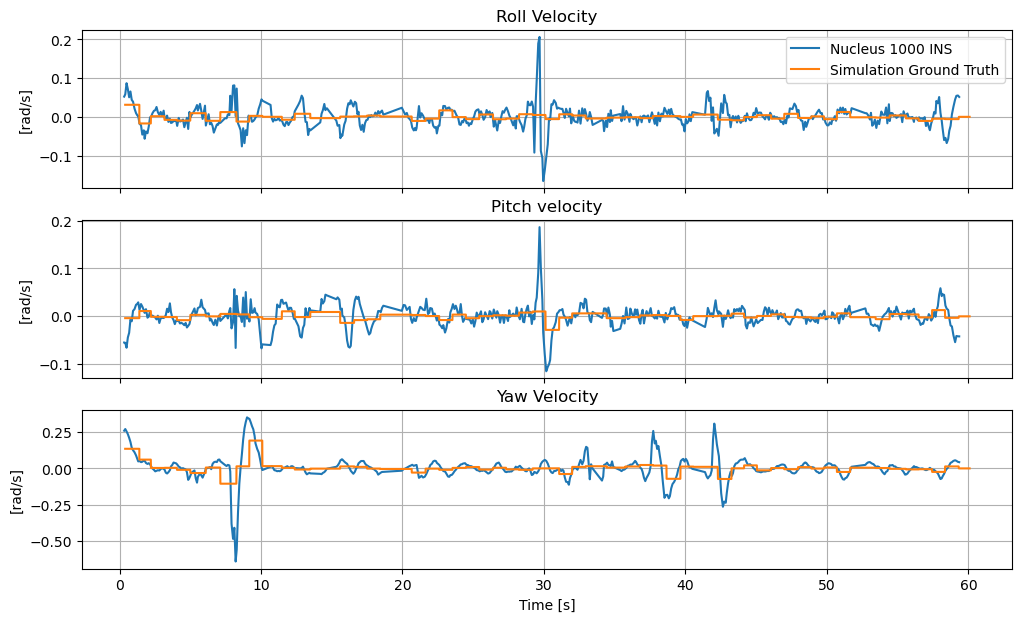

In [324]:
rpy_vel = np.column_stack((np.deg2rad(nucleus_ins["turnRate.x"].values), np.deg2rad(nucleus_ins["turnRate.z"].values), np.deg2rad(-nucleus_ins["turnRate.y"].values)))


fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(ins_data.t, rpy_vel[:,0], label="Nucleus 1000 INS")
axes[0].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.x"].values, label="Simulation Ground Truth")
axes[0].set_title("Roll Velocity")
axes[0].set_ylabel("[rad/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ins_data.t, rpy_vel[:,1])
axes[1].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.y"].values)
axes[1].set_title("Pitch velocity")
axes[1].set_ylabel("[rad/s]")
axes[1].grid(True)

axes[2].plot(ins_data.t, rpy_vel[:,2])
axes[2].plot(sim_gt["t"].values, sim_gt["twist.twist.angular.z"].values)
axes[2].set_title("Yaw Velocity")
axes[2].set_ylabel("[rad/s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

comp_roll = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.x"].values,
                        ins_data.t, rpy_vel[:,0])

comp_pitch = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.y"].values,
                        ins_data.t, rpy_vel[:,1])

comp_yaw = compare_signals(sim_gt["t"].values, sim_gt["twist.twist.linear.z"].values,
                        ins_data.t, rpy_vel[:,2])

print(comp_roll)
print(comp_pitch)
print(comp_yaw)

# Beams

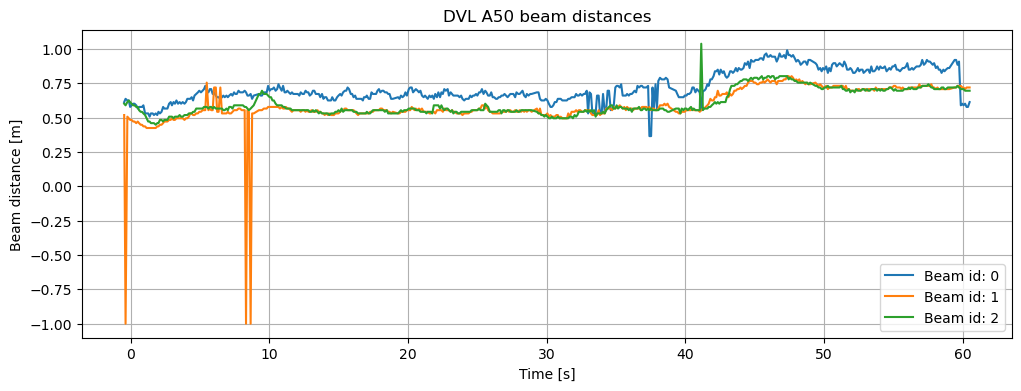

In [325]:
plt.figure(figsize=(12, 4))

# --- DVL-A50 ---
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.0.distance"].values, label="Beam id: 0")
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.1.distance"].values, label="Beam id: 1")
plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["beams.2.distance"].values, label="Beam id: 2")

plt.title("DVL A50 beam distances")
plt.xlabel("Time [s]")
plt.ylabel("Beam distance [m]")

# plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()

# INS Linear velocity 
# TODO: Fjern konstant g!

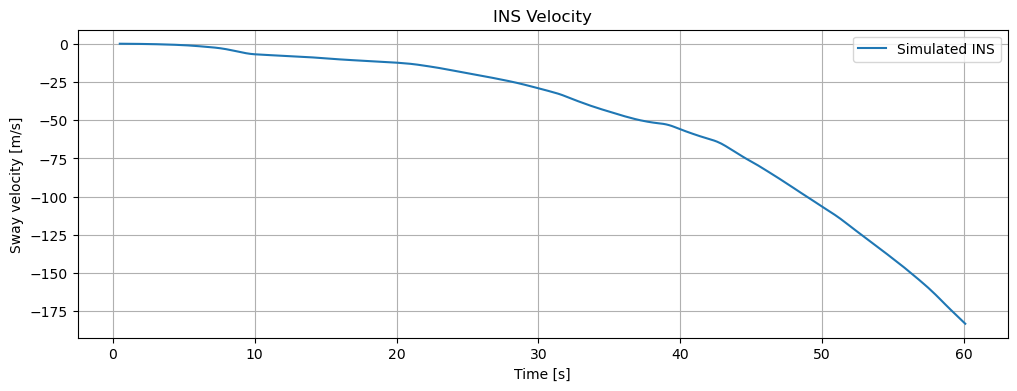

In [326]:
plt.figure(figsize=(12, 4))

plt.plot(sim_ins["t"].values, -sim_ins["pose.north"].values, label="Simulated INS")

# plt.plot(nucleus_ins["t"].values, nucleus_ins["velocityNed.x"].values, label="Nucleus 1000 INS")

# plt.plot(sim_gt["t"].values, -sim_gt["twist.twist.linear.y"].values-0.1, label="Simulation Ground Truth")

plt.title("INS Velocity")
plt.xlabel("Time [s]")
plt.ylabel("Sway velocity [m/s]")

# plt.ylim((-0.05, 0.25))

plt.legend()
plt.grid()

# Net Distance

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


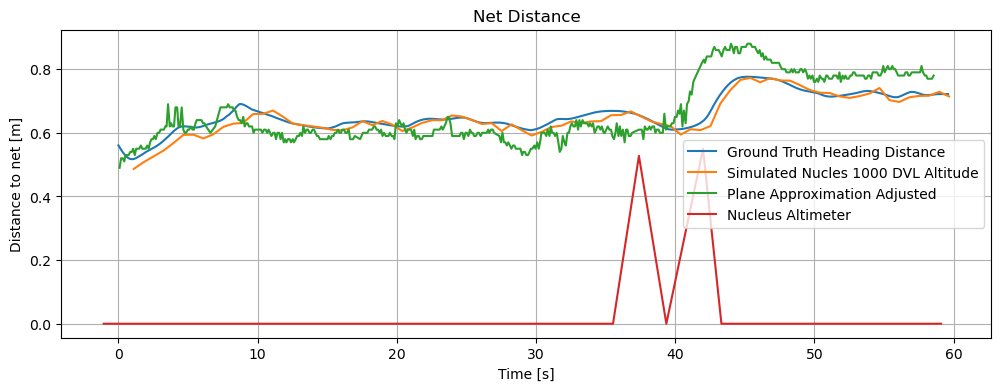

In [327]:
heading_dist_gt = get_profiler_data(SIM_BAG_PATH, "/heading_distance_ground_truth")
plane_approximation = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/navigation/plane_approximation")
normalize_time(plane_approximation)


# Remove outliers and bias
plane_approx_copy = plane_approximation.copy()
plane_approx_copy["diff"] = plane_approx_copy["NetDistance"].diff()
plane_approx_copy = plane_approx_copy[abs(plane_approx_copy["diff"]) <= 0.1]


dist_dvl_imu = 0.178

plt.figure(figsize=(12, 4))
plt.plot(heading_dist_gt["time"], np.array(heading_dist_gt["ranges"]) + dist_dvl_imu, label="Ground Truth Heading Distance")
plt.plot(sim_dvl["t"].values, sim_dvl["altitude"].values + dist_dvl_imu, label="Simulated Nucles 1000 DVL Altitude")
# plt.plot(dvl_a50_velocity["t"].values, dvl_a50_velocity["altitude"].values, label="DVL-A50 Altitude")

# plt.plot(plane_approximation["t"].values, plane_approximation["NetDistance"].values, label="Plane Approximation")
plt.plot(plane_approx_copy["t"].values, plane_approx_copy["NetDistance"].values, label="Plane Approximation Adjusted")


plt.plot(nucleus_alitmeter["t"].values, nucleus_alitmeter["altimeter_distance"].values, label="Nucleus Altimeter")


plt.title("Net Distance")
plt.xlabel("Time [s]")
plt.ylabel("Distance to net [m]")
plt.legend()
plt.grid()

Liten avvik i starten er mest sannsynlig på grunn av vinkelen på roven. Siden dvl har en vinkel på 4 beams.

# Pressure

In [328]:
# Read csv
real_depth_df = bag_topic_to_dataframe(bag_path=REAL_BAG_PATH, topic="/sensor/depth_temperature")
sim_depth_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/pressure")
sim_depth_gt_df = bag_topic_to_dataframe(bag_path=SIM_BAG_PATH, topic="/ground_truth")

set_t0(real_depth_df, t0_real)
set_t0(sim_depth_df, t0_sim)
set_t0(sim_depth_gt_df, t0_sim)

RHO = 1031 # [kg/m^3]
g = 9.81

/root/stonefish_ros2_ws/plots/tools/bag_to_df.py:236: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


{'rmse': 0.01031184270022413, 'corr': 0.9786347738246896, 'mean_error': 0.00041752128200769613, 'var_signal1': 0.0024739495016863986, 'var_signal2': 0.0024973193956094337, 'var_difference': -2.3369893923035068e-05, 'var_ratio_s1_over_s2': 0.9906420084014396, 'cv_signal1': 0.023177241998079297, 'cv_signal2': 0.023290986734316555, 'kurtosis_signal1': -1.7811728694283673, 'kurtosis_signal2': -1.8289278972430296, 'kurtosis_difference': 0.04775502781466234}


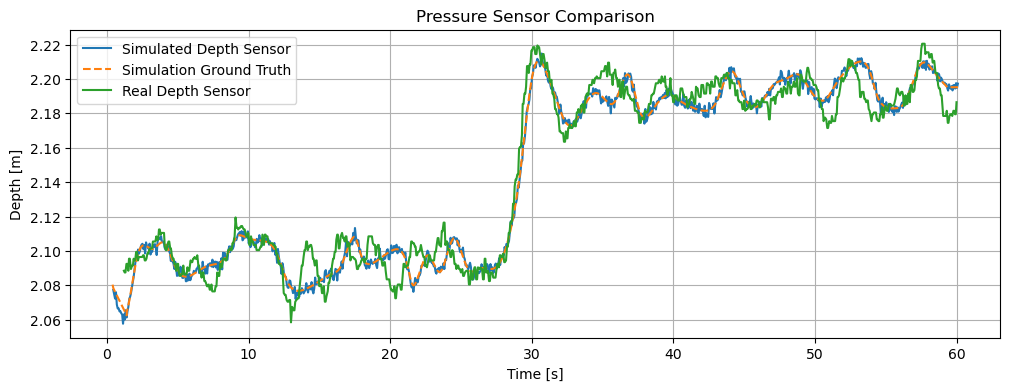

In [329]:
# Remove offset
real_depth_df["depth"] -= real_depth_df["depth"].mean()
real_depth_df["depth"] += sim_gt["pose.pose.position.z"].mean()

# get array of data
depth_real = real_depth_df["depth"].values
depth_sim = (sim_depth_df["fluid_pressure"].values) / (RHO * g)
sim_depth_gt = sim_depth_gt_df["pose.pose.position.z"].values
t_sim = sim_depth_df["t"].values
t_sim_gt = sim_depth_gt_df["t"].values
t_real = real_depth_df["t"].values

lag_sec = get_signal_lag(t_sim_gt, sim_depth_gt,
                        t_real, depth_real)

plt.figure(figsize=(12, 4))
plt.plot(t_sim, depth_sim, label="Simulated Depth Sensor")
plt.plot(t_sim_gt, sim_depth_gt, label="Simulation Ground Truth", ls="--")
plt.plot(t_real - lag_sec, depth_real, label="Real Depth Sensor")

plt.title("Pressure Sensor Comparison")
plt.xlabel("Time [s]")
plt.ylabel("Depth [m]")
plt.legend()
plt.grid()


"""
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(real_depth_df["t"].values, real_depth_df["depth"].values, label="Depth sensor")
axes[0].plot(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values, label="Simulation Ground Truth")
# axes[0].plot(nucleus_ins["t"].values, xyz_transformed[:,2], label="Nucleus INS Position")
axes[0].set_title("Depth Comparison")
axes[0].set_ylabel("Depth [m]")
axes[0].legend()
axes[0].grid(True)


axes[1].plot(sim_depth_df["t"].values, depth_sim, label="Simulated Depth sensor")
axes[1].plot(sim_gt["t"].values, sim_gt["pose.pose.position.z"].values, label="Simulation Ground Truth")
# axes[1].set_title("Surge Velocity")
axes[1].set_ylabel("Depth [m]")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(real_depth_df["t"].values, real_depth_df["depth"].values, label="Depth Sensor")
axes[2].plot(sim_depth_df["t"].values, depth_sim, label="Depth sensor")
axes[2].set_title("Surge Velocity")
axes[2].set_ylabel("Depth [m]")
axes[2].legend()
axes[2].grid(True)
"""


comp_depth = compare_signals(t_real - lag_sec, depth_real,
                        t_sim, depth_sim)

print(comp_depth)

Comparing gague pressure

In [330]:
# IMU Comparison
print_df_frequency(nucleus_imu)

Avg. frequency: 95.97 Hz


{'rmse': 0.14238818461215935, 'corr': 0.3812578253635064, 'mean_error': -0.061191046410575586, 'var_signal1': 0.01903026108915613, 'var_signal2': 0.00481680044726317, 'var_difference': 0.01421346064189296, 'var_ratio_s1_over_s2': 3.9508095254327644, 'cv_signal1': 0.7013281870774443, 'cv_signal2': 0.2691197465206862, 'kurtosis_signal1': 2.2489461884224777, 'kurtosis_signal2': 0.3829406112859961, 'kurtosis_difference': 1.8660055771364816}
{'rmse': 1.0081495060553594, 'corr': 0.3329497122372265, 'mean_error': -0.999869494111558, 'var_signal1': 0.014847452873347582, 'var_signal2': 0.009847495593821311, 'var_difference': 0.004999957279526271, 'var_ratio_s1_over_s2': 1.507738970978919, 'cv_signal1': 1.7288998129309112, 'cv_signal2': 0.10677372636434652, 'kurtosis_signal1': 0.6469150861475832, 'kurtosis_signal2': 1.3839935171635052, 'kurtosis_difference': -0.737078431015922}
{'rmse': 0.0831336875651314, 'corr': 0.100948065236774, 'mean_error': 0.011300484498779928, 'var_signal1': 0.0047323754

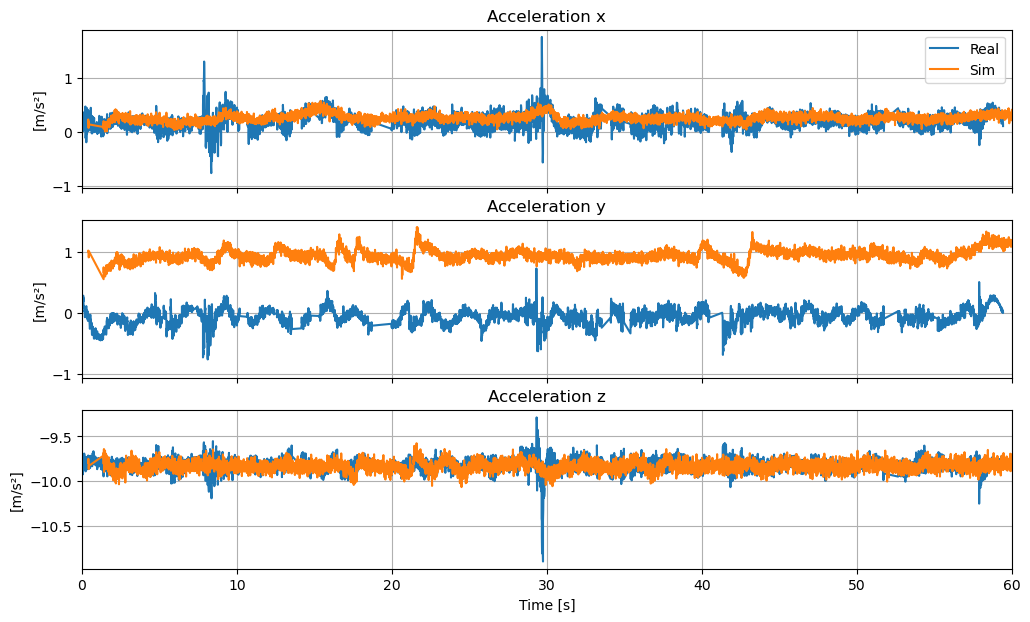

In [331]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(nucleus_imu["t"].values, nucleus_imu["accelerometer.x"].values, label="Real")
axes[0].plot(sim_imu["t"].values, sim_imu["linear_acceleration.x"].values, label="Sim")
axes[0].set_title("Acceleration x")
axes[0].set_ylabel("[m/s²]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(nucleus_imu["t"].values, nucleus_imu["accelerometer.z"].values, label="Real")
axes[1].plot(sim_imu["t"].values, sim_imu["linear_acceleration.y"].values, label="Sim")
axes[1].set_title("Acceleration y")
axes[1].set_ylabel("[m/s²]")
axes[1].grid(True)

axes[2].plot(nucleus_imu["t"].values, -nucleus_imu["accelerometer.y"].values, label="Real")
axes[2].plot(sim_imu["t"].values, sim_imu["linear_acceleration.z"].values, label="Sim")
axes[2].set_title("Acceleration z")
axes[2].set_ylabel("[m/s²]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

axes[0].set_xlim((0, 60))


acc_x = compare_signals(nucleus_imu["t"].values, nucleus_imu["accelerometer.x"].values,
                        sim_imu["t"].values, sim_imu["linear_acceleration.x"].values)

acc_y = compare_signals(nucleus_imu["t"].values, nucleus_imu["accelerometer.z"].values,
                        sim_imu["t"].values, sim_imu["linear_acceleration.y"].values)

acc_z = compare_signals(nucleus_imu["t"].values, -nucleus_imu["accelerometer.y"].values,
                        sim_imu["t"].values, sim_imu["linear_acceleration.z"].values)

print(acc_x)
print(acc_y)
print(acc_z)

Simulerer ikke dorpouts

(0.0, 60.0)

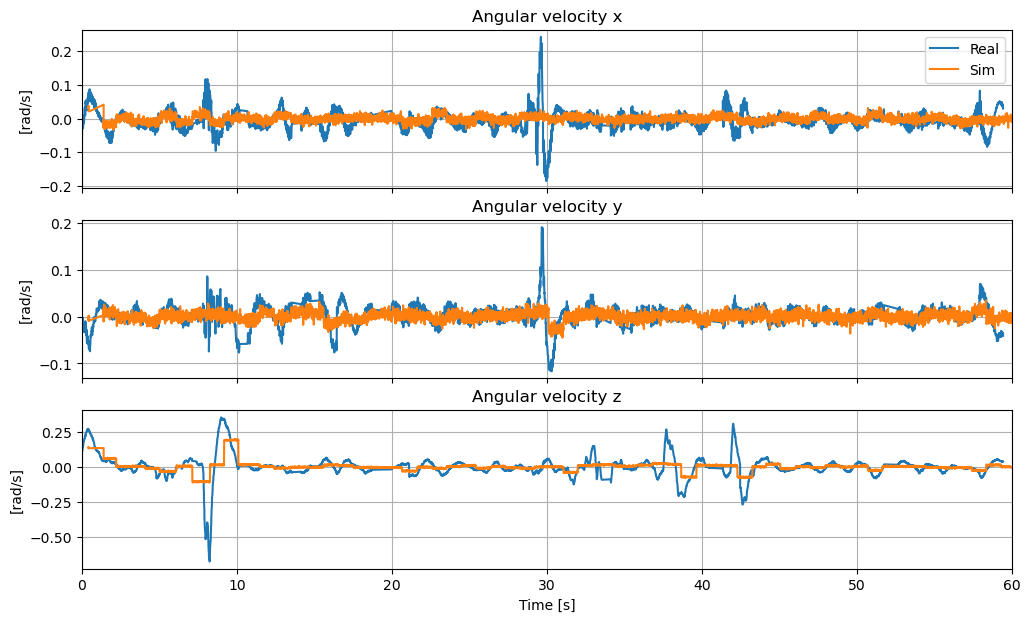

In [332]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(nucleus_imu["t"].values, nucleus_imu["gyroscope.x"].values, label="Real")
axes[0].plot(sim_imu["t"].values, sim_imu["angular_velocity.x"].values, label="Sim")
axes[0].set_title("Angular velocity x")
axes[0].set_ylabel("[rad/s]")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(nucleus_imu["t"].values, nucleus_imu["gyroscope.z"].values, label="Real")
axes[1].plot(sim_imu["t"].values, sim_imu["angular_velocity.y"].values, label="Sim")
axes[1].set_title("Angular velocity y")
axes[1].set_ylabel("[rad/s]")
axes[1].grid(True)

axes[2].plot(nucleus_imu["t"].values, -nucleus_imu["gyroscope.y"].values, label="Real")
axes[2].plot(sim_imu["t"].values, sim_imu["angular_velocity.z"].values, label="Sim")
axes[2].set_title("Angular velocity z")
axes[2].set_ylabel("[rad/s]")
axes[2].set_xlabel("Time [s]")
axes[2].grid(True)

axes[0].set_xlim((0, 60))

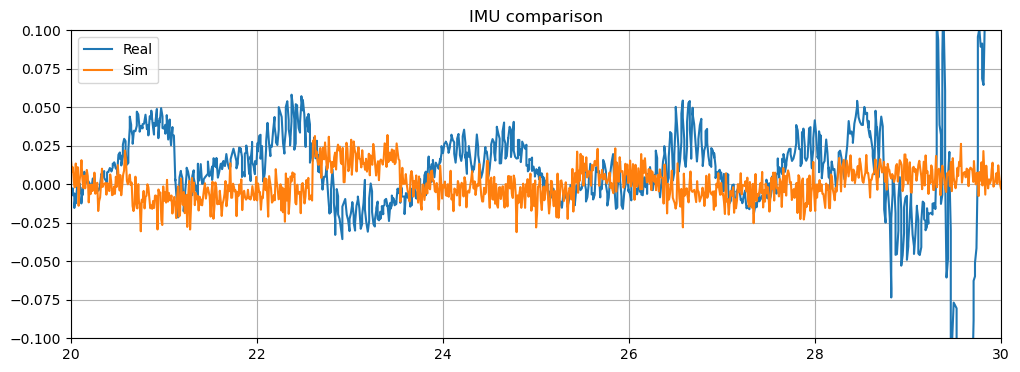

In [333]:
# IMU Comparison
plt.figure(figsize=(12, 4))



plt.plot(nucleus_imu["t"].values, -nucleus_imu["gyroscope.x"].values, label="Real")
plt.plot(sim_imu["t"].values, sim_imu["angular_velocity.x"].values, label="Sim")

plt.legend()


plt.title("IMU comparison")

plt.xlim((20, 30))
plt.ylim((-0.1, 0.1))

plt.legend()
plt.grid()